#### **Quem carrega o sinal? Endividamento, juros e o canal das bets (v4)**

A v3 mostrou que a **taxa efetiva** paga pelas pessoas físicas (SGS 20716) antecede a
inadimplência de forma robusta. Esta quarta versão dá um passo atrás para perguntar
**de quem é o sinal**: dos juros, do **endividamento** das famílias, do
**comprometimento de renda** ou de todos juntos?

Acrescentamos o **comprometimento de renda** (SGS 29034, serviço da dívida em % da
renda, com ajuste sazonal) para separar dois conceitos:

- **endividamento** (SGS 29037): estoque da dívida em relação à renda;
- **comprometimento**: parcela da renda comprometida com o pagamento da dívida.

E voltamos ao tema das **bets**: onde elas entrariam no modelo e por que, com os
dados disponíveis, não podem ser medidas.

> **Resumo executivo.** O **comprometimento de renda** e o **endividamento** ajudam a
> prever a inadimplência, mas a resposta à **taxa efetiva** sobrevive a todos os
> controles (pico em ~6 meses). A cointegração é frágil — depende de quais variáveis
> entram. E as **bets** seguem como ameaça não mensurável.

#### **Preparando a bancada de análise**

Mesmas ferramentas das versões anteriores. Reaproveitamos `local_projections.py` e
`toda_yamamoto.py`.

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import select_coint_rank, VECM
from statsmodels.stats.outliers_influence import variance_inflation_factor
from arch.unitroot import ZivotAndrews

from toda_yamamoto import toda_yamamoto_causality
from local_projections import local_projection, resultados_para_dataframe

sns.set()
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

#### **1. Carregamento e engenharia**

Sete séries no período comum. Derivamos ainda a **taxa de juros real** (taxa efetiva
deflacionada pelo IPCA em 12 meses).

In [2]:
df = pd.read_csv('../data/processed/dataset_consolidado.csv', parse_dates=['data'])
df = df.set_index('data').sort_index()

df['ipca_12m'] = df['ipca'].rolling(12).apply(
    lambda s: (np.prod(1 + s / 100) - 1) * 100, raw=True
)
df['juros_real'] = ((1 + df['juros_efetivos_pf'] / 100) /
                    (1 + df['ipca_12m'] / 100) - 1) * 100

series = ['taxa_juros', 'juros_efetivos_pf', 'inadimplencia_pf', 'ipca',
          'endividamento_familias', 'comprometimento_renda', 'ibc_br']
print(f"Período: {df.index.min():%Y-%m} a {df.index.max():%Y-%m} | {len(df)} observações mensais")
print('Valores ausentes:', int(df[series].isna().sum().sum()))
print(f"Juros efetivos PF: mediana {df['juros_efetivos_pf'].median():.1f}% a.a. "
      f"vs referencial {df['taxa_juros'].median():.1f}% a.a.")
print('Correlação endividamento x comprometimento: '
      f"nível {df[['endividamento_familias','comprometimento_renda']].corr().iloc[0,1]:.2f} | "
      f"1ª dif. {df[['endividamento_familias','comprometimento_renda']].diff().corr().iloc[0,1]:.2f}")
df[series].describe().T[['count', 'mean', 'std', 'min', 'max']]

Período: 2011-03 a 2026-07 | 185 observações mensais
Valores ausentes: 0
Juros efetivos PF: mediana 32.5% a.a. vs referencial 11.0% a.a.
Correlação endividamento x comprometimento: nível 0.82 | 1ª dif. 0.56


,count,mean,std,min,max
taxa_juros,185.0000,10.0789,3.7310,2.0000,15.0000
juros_efetivos_pf,185.0000,32.6536,4.6587,22.6500,42.2900
inadimplencia_pf,185.0000,4.0898,0.6855,2.8900,5.8000
ipca,185.0000,0.4653,0.3611,-0.6800,1.6200
endividamento_familias,185.0000,42.0998,4.9451,34.8600,49.9200
comprometimento_renda,185.0000,24.2913,2.0545,19.7700,28.7200
ibc_br,185.0000,99.8465,5.0924,82.9653,111.1385


As duas medidas de endividamento andam juntas (≈0,82 em nível), mas não são
idênticas: uma é **estoque**, a outra é **serviço da dívida**. A distinção importa
porque a inadimplência depende mais do **fluxo de pagamento** do que do estoque.

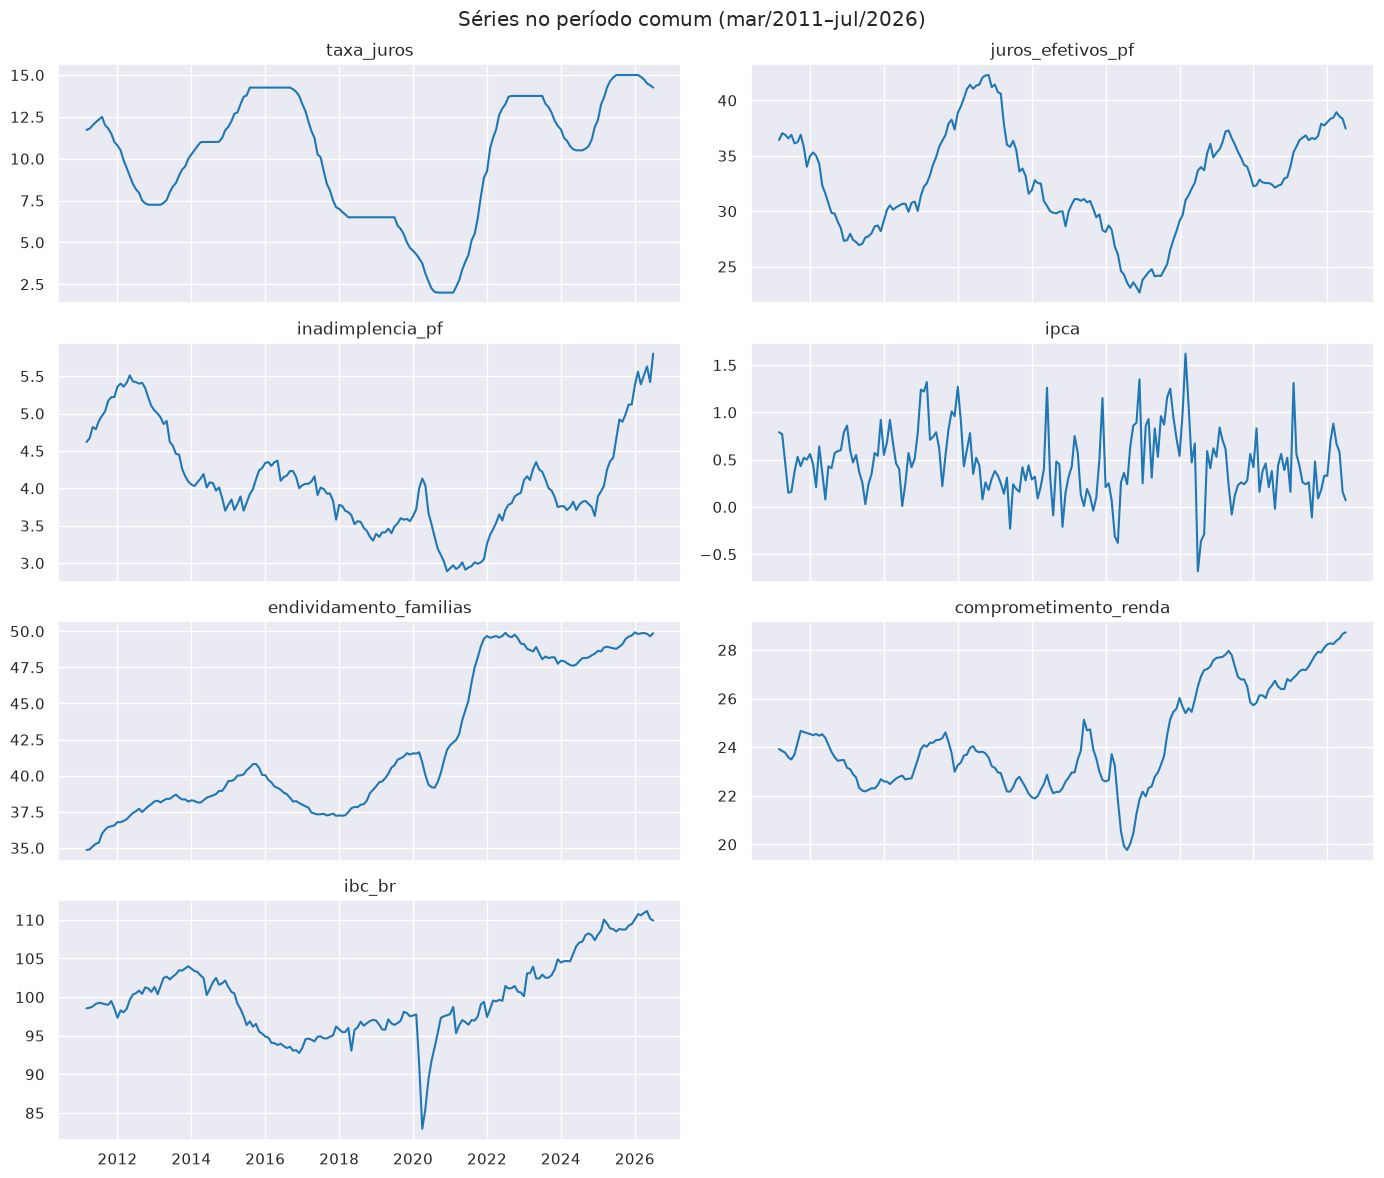

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
for ax, coluna in zip(axes.ravel(), series):
    ax.plot(df.index, df[coluna], color='tab:blue')
    ax.set_title(coluna)
axes.ravel()[-1].axis('off')
fig.suptitle('Séries no período comum (mar/2011–jul/2026)')
plt.tight_layout()
plt.show()

#### **2. As séries são estacionárias?**

ADF, KPSS e Zivot–Andrews (que admite uma quebra estrutural).

In [4]:
def resumo_estacionariedade(serie, nome):
    serie = serie.dropna()
    return {
        'série': nome,
        'ADF p (nível)': adfuller(serie, autolag='AIC')[1],
        'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
        'Zivot–Andrews p (nível)': ZivotAndrews(serie).pvalue,
        'ADF p (1ª dif.)': adfuller(serie.diff().dropna(), autolag='AIC')[1],
    }

pd.DataFrame([resumo_estacionariedade(df[c], c) for c in series]).set_index('série')

/tmp/ipykernel_161708/816872038.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
/tmp/ipykernel_161708/816872038.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
/tmp/ipykernel_161708/816872038.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
/tmp/ipykernel_161708/816872038.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-va

,ADF p (nível),KPSS p (nível),Zivot–Andrews p (nível),ADF p (1ª dif.)
série,,,,
taxa_juros,0.4836,0.1000,0.7711,0.0003
juros_efetivos_pf,0.1011,0.1000,0.2776,0.0030
inadimplencia_pf,0.3580,0.0375,0.9920,0.0703
ipca,0.0000,0.1000,0.0000,0.0000
endividamento_familias,0.8189,0.0100,0.0158,0.0003
comprometimento_renda,0.7517,0.0100,0.0854,0.0090
ibc_br,0.7512,0.0145,0.5338,0.0000


Os juros (referencial e efetivo), o endividamento, o comprometimento e o IBC-Br são
tratados como **I(1)**; o IPCA, como I(0). A inadimplência segue limítrofe na
primeira diferença (ADF ≈ 0,07), mas mantemos **`dmax = 1`** por prudência. A maior
ordem de integração é 1.

#### **3. Multicolinearidade e cointegração — atenção à composição**

Antes de estimar, checamos se os controles são redundantes (VIF) e se existe relação
de longo prazo. Um ponto importante: **o resultado da cointegração depende de quais
variáveis entram**.

In [5]:
controles = ['juros_efetivos_pf', 'ipca', 'endividamento_familias',
             'comprometimento_renda', 'ibc_br']
base_vif = df[controles].diff().dropna()
vif = pd.DataFrame({
    'variável': controles,
    'VIF': [variance_inflation_factor(base_vif.values, i) for i in range(len(controles))],
})
vif

,variável,VIF
0,juros_efetivos_pf,1.1093
1,ipca,1.0187
2,endividamento_familias,1.5229
3,comprometimento_renda,1.7069
4,ibc_br,1.1271


In [6]:
conjuntos = {
    'A) referencial (432) + IPCA + endividamento': ['taxa_juros', 'inadimplencia_pf', 'ipca', 'endividamento_familias'],
    'B) efetiva (20716) + endividamento': ['juros_efetivos_pf', 'inadimplencia_pf', 'endividamento_familias'],
    'C) efetiva + endividamento + comprometimento': ['juros_efetivos_pf', 'inadimplencia_pf', 'endividamento_familias', 'comprometimento_renda'],
    'D) efetiva + endividamento + comprometimento + IPCA': ['juros_efetivos_pf', 'inadimplencia_pf', 'endividamento_familias', 'comprometimento_renda', 'ipca'],
}
linhas = []
for nome, cols in conjuntos.items():
    r = select_coint_rank(df[cols], det_order=0, k_ar_diff=6, method='trace', signif=0.05)
    linhas.append({'conjunto': nome, 'posto de cointegração': r.rank,
                   'estatística': r.test_stats[0], 'crítico 5%': r.crit_vals[0]})
pd.DataFrame(linhas).set_index('conjunto')

,posto de cointegração,estatística,crítico 5%
conjunto,,,
A) referencial (432) + IPCA + endividamento,1,60.1834,47.8545
B) efetiva (20716) + endividamento,0,20.1458,29.7961
C) efetiva + endividamento + comprometimento,0,33.2986,47.8545
D) efetiva + endividamento + comprometimento + IPCA,1,83.1608,69.8189


Os VIFs são baixos (< 2), então os controles não são redundantes. Já a cointegração é
**instável**: aparece **posto 1** quando o IPCA entra no conjunto (A e D) e
**desaparece (posto 0)** sem ele (B e C). Ou seja, a "relação de longo prazo" do v2
dependia daquela composição específica. Isso reforça uma postura cautelosa: usamos
**VAR em diferenças e projeções locais**, que não exigem cointegração.

#### **4. De quem é o sinal? (Granger)**

Testamos o conteúdo preditivo de cada candidato sobre a inadimplência (menor p-valor
do teste F entre 1 e 6 defasagens) — e também o sentido inverso para os juros, por
causa do *feedback*.

In [7]:
d = df[series].diff().dropna()

def granger_min_p(causa, efeito='inadimplencia_pf', maxlag=6):
    resultado = grangercausalitytests(d[[efeito, causa]].dropna(), maxlag=maxlag)
    return min(resultado[lag][0]['ssr_ftest'][1] for lag in range(1, maxlag + 1))

linhas = []
for causa in ['juros_efetivos_pf', 'taxa_juros', 'endividamento_familias',
              'comprometimento_renda', 'ipca', 'ibc_br']:
    linhas.append({'causa → inadimplência': causa, 'menor p (F)': granger_min_p(causa)})
linhas.append({'causa → inadimplência': 'inadimplência → juros_efetivos_pf',
               'menor p (F)': granger_min_p('inadimplencia_pf', 'juros_efetivos_pf')})
pd.DataFrame(linhas).set_index('causa → inadimplência').round(4)

,menor p (F)
causa → inadimplência,
juros_efetivos_pf,0.0001
taxa_juros,0.0080
endividamento_familias,0.0080
comprometimento_renda,0.0000
ipca,0.2013
ibc_br,0.0013
inadimplência → juros_efetivos_pf,0.0101


O **comprometimento de renda** é o preditor mais forte da inadimplência (p < 0,001),
seguido de perto pelos **juros efetivos** e pelo **IBC-Br**; o endividamento (estoque)
e a referencial vêm atrás. Mas há um alerta: o sentido inverso **inadimplência →
juros efetivos** também é significativo (p ≈ 0,01). Isso é **feedback**, não uma via
de mão única — mais um motivo para falar em previsão condicional, não em causalidade.

In [8]:
linhas = []
for dmax in (1, 2):
    for causa in ('juros_efetivos_pf', 'taxa_juros'):
        r = toda_yamamoto_causality(df, causa, 'inadimplencia_pf',
                                    selected_lags=6, max_integration_order=dmax)
        linhas.append({'dmax': dmax, 'causa': causa, 'Wald': r.wald_statistic,
                       'gl': r.degrees_of_freedom, 'p_valor': r.p_value})
pd.DataFrame(linhas)

,dmax,causa,Wald,gl,p_valor
0,1,juros_efetivos_pf,28.1932,6,0.0001
1,1,taxa_juros,13.1528,6,0.0407
2,2,juros_efetivos_pf,27.0188,6,0.0001
3,2,taxa_juros,9.8112,6,0.1328


No Toda–Yamamoto, a taxa **efetiva** permanece significativa com `dmax=1` e `dmax=2`
(p ≈ 0,0001); a referencial oscila (p ≈ 0,04 e 0,13). O resultado robusto é dos
juros efetivos — coerente com a v3.

#### **5. Horse race: a resposta aos juros sobrevive aos controles?**

Estimamos a resposta da inadimplência a um choque de **1 desvio-padrão** na taxa
efetiva, variando os controles.

In [9]:
d2 = df[series + ['juros_real']].diff()
d2['juros_efetivos_pf'] = d2['juros_efetivos_pf'] / d2['juros_efetivos_pf'].std()

especs = {
    'base (sem controles)': [],
    '+ IPCA': ['ipca'],
    '+ endividamento': ['endividamento_familias'],
    '+ comprometimento': ['comprometimento_renda'],
    '+ endividamento + comprometimento': ['endividamento_familias', 'comprometimento_renda'],
    '+ todos': ['ipca', 'endividamento_familias', 'comprometimento_renda', 'ibc_br'],
}
lps = {}
for nome, ctrl in especs.items():
    lps[nome] = resultados_para_dataframe(
        local_projection(d2, 'inadimplencia_pf', 'juros_efetivos_pf',
                         horizons=24, lags=6, controls=ctrl)
    )
    tabela = lps[nome]
    significativos = [h for h in tabela.index if tabela.loc[h, 'p_valor'] < 0.05]
    print(f"{nome:38s} p<0,05 em {significativos}")

base (sem controles)                   p<0,05 em [0, 2, 3, 6, 7, 8, 11, 12, 13, 14, 18, 20, 21]
+ IPCA                                 p<0,05 em [0, 2, 3, 6, 7, 8, 11, 12, 14, 18, 21]


+ endividamento                        p<0,05 em [2, 5, 6, 12, 13, 18, 21]
+ comprometimento                      p<0,05 em [2, 6, 11, 12, 13, 14, 18, 21]


+ endividamento + comprometimento      p<0,05 em [2, 6, 12, 13, 18, 21]


+ todos                                p<0,05 em [2, 6, 11, 12, 18, 21]


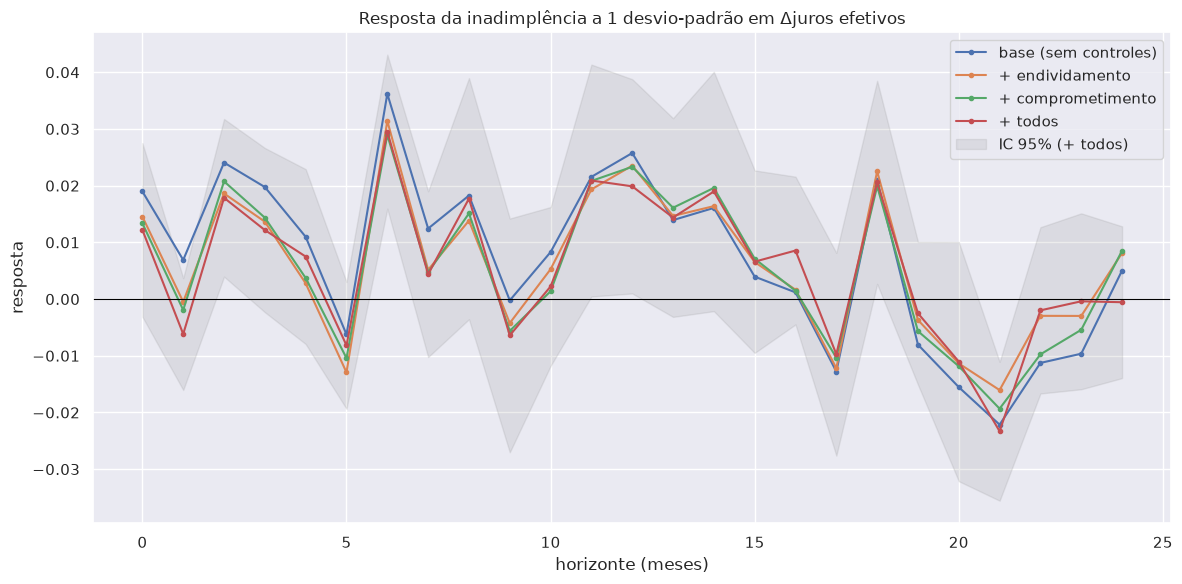

In [10]:
fig, eixo = plt.subplots(figsize=(12, 6))
for nome in ['base (sem controles)', '+ endividamento', '+ comprometimento', '+ todos']:
    tabela = lps[nome]
    eixo.plot(tabela.index, tabela['coeficiente'], marker='o', markersize=3, label=nome)
eixo.fill_between(lps['+ todos'].index, lps['+ todos']['ic_inferior'],
                  lps['+ todos']['ic_superior'], color='gray', alpha=0.15,
                  label='IC 95% (+ todos)')
eixo.axhline(0, color='black', linewidth=0.8)
eixo.legend()
eixo.set_title('Resposta da inadimplência a 1 desvio-padrão em Δjuros efetivos')
eixo.set_xlabel('horizonte (meses)')
eixo.set_ylabel('resposta')
plt.tight_layout()
plt.show()

O formato é o mesmo em todas as especificações: a resposta **nasce perto de zero,
cresce e atinge o pico em ~6 meses**, e os juros não perdem significância quando o
endividamento e o comprometimento entram. Ou seja: o sinal dos juros **não é
absorvido** pelas medidas de dívida das famílias.

#### **6. O canal das bets (exploratório)**

Se as bets aumentam o endividamento, elas estariam **a montante** da dívida:

```
bets → menos renda disponível / nova dívida → endividamento ↑ → inadimplência ↑
```

O problema é de dado: **não existe série pública mensal de bets** (o portal do BCB
não expõe "EPAE"/"apostas" e a API do Pix não abre por atividade). Então fazemos só
checagens exploratórias com o que temos.

In [11]:
df['pos2023'] = (df.index >= '2023-01-01').astype(int)
print('Meses após 2023:', int(df['pos2023'].sum()))

X = sm.add_constant(df['pos2023'])
ajuste = sm.OLS(df['inadimplencia_pf'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
print(f"Deslocamento pós-2023: {ajuste.params['pos2023']:+.3f} p.p. (p={ajuste.pvalues['pos2023']:.3f})")
print(f"Zivot–Andrews na inadimplência: p={ZivotAndrews(df['inadimplencia_pf']).pvalue:.3f}")

Meses após 2023: 43
Deslocamento pós-2023: +0.355 p.p. (p=0.203)
Zivot–Andrews na inadimplência: p=0.992


In [12]:
d_int = d2.copy()
d_int['pos2023'] = (d_int.index >= '2023-01-01').astype(int)

def lp_interacao(dados, horizonte, lags=6):
    base = dados.copy()
    y = base['inadimplencia_pf'].shift(-horizonte)
    X = pd.DataFrame(index=base.index)
    X['const'] = 1.0
    X['juros'] = base['juros_efetivos_pf']
    X['pos2023'] = base['pos2023']
    X['juros_pos2023'] = base['juros_efetivos_pf'] * base['pos2023']
    for j in range(1, lags + 1):
        X[f'inad_lag{j}'] = base['inadimplencia_pf'].shift(j)
        X[f'juros_lag{j}'] = base['juros_efetivos_pf'].shift(j)
    alinhado = pd.concat([y.rename('y'), X], axis=1).dropna()
    return sm.OLS(alinhado['y'], alinhado.drop(columns='y')).fit(
        cov_type='HAC', cov_kwds={'maxlags': horizonte + lags}
    )

linhas = []
for horizonte in [0, 3, 6, 9, 12, 18, 24]:
    ajuste = lp_interacao(d_int, horizonte)
    linhas.append({'horizonte': horizonte, 'interação': ajuste.params['juros_pos2023'],
                   'p_valor': ajuste.pvalues['juros_pos2023']})
pd.DataFrame(linhas).set_index('horizonte')

,interação,p_valor
horizonte,,
0,0.0195,0.3702
3,0.0513,0.0127
6,0.0202,0.4768
9,0.0213,0.3780
12,-0.0194,0.3169
18,-0.0366,0.1998
24,-0.0206,0.3878


Não há deslocamento significativo pós-2023 (p ≈ 0,20) nem quebra estrutural
(Zivot–Andrews p ≈ 0,99), e a interação `juros × pós-2023` **troca de sinal** entre
horizontes — sem mudança estável do canal. Conclusão honesta: as bets são uma
**ameaça real à interpretação**, mas **não mensurável** com os dados disponíveis.
Elas entrariam como determinante do **endividamento** (a montante), não como
variável do canal de juros.

#### **7. Robustez: sem os meses da pandemia**

Reestimamos o horse race excluindo mar/2020–dez/2021.

In [13]:
na_pandemia = (d2.index >= '2020-03-01') & (d2.index <= '2021-12-01')
d_sem = d2.loc[~na_pandemia]
lp_robusto = resultados_para_dataframe(
    local_projection(d_sem, 'inadimplencia_pf', 'juros_efetivos_pf', horizons=24, lags=6,
                     controls=['ipca', 'endividamento_familias', 'comprometimento_renda', 'ibc_br'])
)
print('Horizontes com p < 0,05 (sem pandemia):',
      [h for h in lp_robusto.index if lp_robusto.loc[h, 'p_valor'] < 0.05])

Horizontes com p < 0,05 (sem pandemia): [0, 2, 6, 8, 13]


#### **8. O que aprendemos — e o que ainda não sabemos**

Sobre 185 meses (mar/2011–jul/2026):

- **O comprometimento de renda é o preditor mais forte** da inadimplência, seguido
  pelos juros efetivos. O endividamento (estoque) e a referencial vêm atrás.
- **A resposta aos juros sobrevive a todos os controles**, com pico em ~6 meses.
- **A cointegração é frágil**: some quando tiramos o IPCA do conjunto — por isso a
  análise se apoia em diferenças/projeções locais.
- **Há feedback** (inadimplência → juros efetivos também é significativo, p ≈ 0,01):
  previsão bidirecional, não via causal única.
- **As bets** seguem sem série pública; entrariam a montante do endividamento e
  ficam como limitação.

Em linguagem direta: **juros e comprometimento de renda caminham juntos como
sinalizadores da inadimplência; nenhum anula o outro, e a leitura causal continua
fora de alcance com estes dados.**

#### **Para o time de negócios**

**Conclusão:** juros efetivos e **comprometimento de renda** são os melhores
sinalizadores da inadimplência futura; o endividamento (estoque) ajuda, mas menos.

- **Monitore dois indicadores, não um:** taxa efetiva PF (SGS 20716) **e**
  comprometimento de renda (SGS 29034).
- **A defasagem típica é de ~6 meses** — janela para provisão e cobrança.
- **O efeito dos juros não desaparece** ao controlar pela dívida das famílias.
- **As bets são um risco não mensurável** no fim da amostra; mantenha um monitor
  qualitativo.
- **É previsão, não causa.** Há feedback entre inadimplência e juros; não use para
  prometer causalidade.

**O que fazer:** adotar o **par juros efetivos + comprometimento** como painel de
alerta; reforçar provisão/cobrança após ciclos de alta; monitorar bets.

#### **Próximas perguntas**

1. **Bets com dados melhores**: buscar microdados de pagamentos por atividade para
   construir um proxy mensal, quando disponíveis.
2. **Identificação**: restrições de sinal ou instrumentos para separar o choque de
   política monetária do feedback de inadimplência.
3. **Renda e emprego**: incluir renda disponível e desocupação, avaliando o custo em
   potência.